In [ ]:
# ECS7026P Neural Networks and Deep Learning
# Part 1: CIFAR-10 Image Classification
#
# This notebook implements the required intermediate-block architecture
# described in the assignment brief.

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import random
import time

In [ ]:
# Reproducibility setup

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [ ]:
# CIFAR-10 DataLoaders

batch_size = 128

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

classes = train_dataset.classes

print("Training examples:", len(train_dataset))
print("Testing examples:", len(test_dataset))
print("Classes:", classes)

100%|██████████| 170M/170M [00:04<00:00, 42.4MB/s]


Training examples: 50000
Testing examples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Intermediate Block

Each intermediate block applies several independent convolutional layers to the same input image. The block then computes the average value of each input channel, passes this through a fully connected layer, and uses the resulting weights to combine the convolution outputs.

In [ ]:
class IntermediateBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_convs):
        super().__init__()

        self.num_convs = num_convs

        # Independent convolutional layers.
        # Each receives the same input x.
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_size=3,
                    padding=1,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels),
                nn.ReLU()
            )
            for _ in range(num_convs)
        ])

        # Fully connected layer used to compute the weighting coefficients.
        # It receives one average value per input channel.
        self.fc = nn.Linear(in_channels, num_convs)

    def forward(self, x):
        batch_size = x.size(0)

        # Compute the average value of each input channel.
        # Shape: [batch_size, in_channels]
        m = x.mean(dim=(2, 3))

        # Compute the weights for combining convolution outputs.
        # Shape: [batch_size, num_convs]
        weights = self.fc(m)

        # Softmax makes the weights stable and easier to interpret.
        weights = F.softmax(weights, dim=1)

        # Apply each independent convolution to the same input x.
        conv_outputs = [conv(x) for conv in self.convs]

        # Stack outputs.
        # Shape: [batch_size, num_convs, out_channels, height, width]
        conv_outputs = torch.stack(conv_outputs, dim=1)

        # Reshape weights so they can multiply the convolution outputs.
        weights = weights.view(batch_size, self.num_convs, 1, 1, 1)

        # Weighted sum of convolution outputs.
        out = (weights * conv_outputs).sum(dim=1)

        return out

### Sanity check for the intermediate block

In [ ]:
# Test the intermediate block with a fake CIFAR-10 batch

test_block = IntermediateBlock(
    in_channels=3,
    out_channels=32,
    num_convs=3
).to(device)

fake_images = torch.randn(8, 3, 32, 32).to(device)

test_output = test_block(fake_images)

print("Input shape:", fake_images.shape)
print("Output shape:", test_output.shape)

Input shape: torch.Size([8, 3, 32, 32])
Output shape: torch.Size([8, 32, 32, 32])


## Output Block

The output block receives the final feature map, averages each channel, and passes the resulting vector through fully connected layers to produce 10 logits for the CIFAR-10 classes.

In [ ]:
class OutputBlock(nn.Module):
    def __init__(self, in_channels, num_classes=10):
        super().__init__()

        self.classifier = nn.Sequential(
            nn.Linear(in_channels, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # Compute average value of each channel.
        # Shape: [batch_size, in_channels]
        m = x.mean(dim=(2, 3))

        # Produce logits.
        out = self.classifier(m)

        return out

### Sanity check for the output block

In [ ]:
test_output_block = OutputBlock(
    in_channels=32,
    num_classes=10
).to(device)

fake_features = torch.randn(8, 32, 32, 32).to(device)

logits = test_output_block(fake_features)

print("Input feature shape:", fake_features.shape)
print("Logits shape:", logits.shape)

Input feature shape: torch.Size([8, 32, 32, 32])
Logits shape: torch.Size([8, 10])


## Full CIFAR-10 Network

The full model stacks several intermediate blocks and then applies the output block. Pooling layers are added between some blocks to reduce spatial size and make training more efficient.

In [ ]:
class CIFAR10Net(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            IntermediateBlock(in_channels=3, out_channels=32, num_convs=3),
            nn.MaxPool2d(kernel_size=2),   # 32x32 -> 16x16

            IntermediateBlock(in_channels=32, out_channels=64, num_convs=3),
            nn.MaxPool2d(kernel_size=2),   # 16x16 -> 8x8

            IntermediateBlock(in_channels=64, out_channels=128, num_convs=3),
            nn.MaxPool2d(kernel_size=2),   # 8x8 -> 4x4

            IntermediateBlock(in_channels=128, out_channels=256, num_convs=3)
        )

        self.output_block = OutputBlock(
            in_channels=256,
            num_classes=num_classes
        )

    def forward(self, x):
        x = self.features(x)
        out = self.output_block(x)
        return out

### Sanity check for the full model

In [ ]:
model = CIFAR10Net(num_classes=10).to(device)

fake_images = torch.randn(8, 3, 32, 32).to(device)
logits = model(fake_images)

print("Input shape:", fake_images.shape)
print("Output logits shape:", logits.shape)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Input shape: torch.Size([8, 3, 32, 32])
Output logits shape: torch.Size([8, 10])
Total parameters: 1201567
Trainable parameters: 1201567


## Training and Evaluation Functions

The model is trained using cross entropy loss. After each epoch, the training and testing accuracy are recorded so they can be plotted later.

In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    running_correct = 0
    running_total = 0
    batch_losses = []

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and parameter update
        loss.backward()
        optimizer.step()

        # Store batch loss
        batch_losses.append(loss.item())

        # Track training accuracy
        _, predicted = torch.max(outputs, 1)
        running_total += labels.size(0)
        running_correct += (predicted == labels).sum().item()

    epoch_accuracy = 100 * running_correct / running_total

    return batch_losses, epoch_accuracy

In [ ]:
def evaluate(model, data_loader, device):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    return accuracy

## Initial Training Run

This section trains the model and records the loss for each training batch, the training accuracy after each epoch, and the testing accuracy after each epoch.

In [ ]:
model = CIFAR10Net(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=0.0005
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)

num_epochs = 20

all_batch_losses = []
train_accuracies = []
test_accuracies = []

start_time = time.time()

for epoch in range(num_epochs):
    epoch_losses, train_acc = train_one_epoch(
        model=model,
        train_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    test_acc = evaluate(
        model=model,
        data_loader=test_loader,
        device=device
    )

    scheduler.step()

    all_batch_losses.extend(epoch_losses)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Accuracy: {train_acc:.2f}% "
        f"Test Accuracy: {test_acc:.2f}%"
    )

end_time = time.time()

print(f"Training time: {(end_time - start_time) / 60:.2f} minutes")
print(f"Highest test accuracy: {max(test_accuracies):.2f}%")

Epoch [1/20] Train Accuracy: 47.37% Test Accuracy: 58.69%
Epoch [2/20] Train Accuracy: 62.59% Test Accuracy: 59.02%
Epoch [3/20] Train Accuracy: 67.85% Test Accuracy: 63.81%
Epoch [4/20] Train Accuracy: 71.65% Test Accuracy: 65.36%
Epoch [5/20] Train Accuracy: 73.81% Test Accuracy: 70.26%
Epoch [6/20] Train Accuracy: 76.16% Test Accuracy: 64.24%
Epoch [7/20] Train Accuracy: 77.86% Test Accuracy: 70.30%
Epoch [8/20] Train Accuracy: 78.98% Test Accuracy: 73.79%
Epoch [9/20] Train Accuracy: 80.18% Test Accuracy: 74.48%
Epoch [10/20] Train Accuracy: 81.35% Test Accuracy: 80.01%
Epoch [11/20] Train Accuracy: 82.34% Test Accuracy: 77.18%
Epoch [12/20] Train Accuracy: 83.28% Test Accuracy: 79.85%
Epoch [13/20] Train Accuracy: 84.09% Test Accuracy: 82.10%
Epoch [14/20] Train Accuracy: 84.84% Test Accuracy: 82.61%
Epoch [15/20] Train Accuracy: 85.63% Test Accuracy: 82.87%
Epoch [16/20] Train Accuracy: 86.18% Test Accuracy: 83.91%
Epoch [17/20] Train Accuracy: 86.82% Test Accuracy: 84.37%
Epoch 

## Improved Model

The first model achieved 84.76% testing accuracy. To improve performance, this version increases the width of the convolutional blocks, adds dropout before classification, and trains for more epochs using AdamW with cosine learning-rate scheduling.

In [ ]:
class ImprovedCIFAR10Net(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            IntermediateBlock(in_channels=3, out_channels=64, num_convs=4),
            nn.MaxPool2d(kernel_size=2),   # 32x32 -> 16x16

            IntermediateBlock(in_channels=64, out_channels=128, num_convs=4),
            nn.MaxPool2d(kernel_size=2),   # 16x16 -> 8x8

            IntermediateBlock(in_channels=128, out_channels=256, num_convs=4),
            nn.MaxPool2d(kernel_size=2),   # 8x8 -> 4x4

            IntermediateBlock(in_channels=256, out_channels=256, num_convs=4)
        )

        self.output_block = OutputBlock(
            in_channels=256,
            num_classes=num_classes
        )

    def forward(self, x):
        x = self.features(x)
        out = self.output_block(x)
        return out

## Improved Model Training Run

In [ ]:
model = ImprovedCIFAR10Net(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=0.0005
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30
)

num_epochs = 30

all_batch_losses = []
train_accuracies = []
test_accuracies = []

start_time = time.time()

for epoch in range(num_epochs):
    epoch_losses, train_acc = train_one_epoch(
        model=model,
        train_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    test_acc = evaluate(
        model=model,
        data_loader=test_loader,
        device=device
    )

    scheduler.step()

    all_batch_losses.extend(epoch_losses)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Accuracy: {train_acc:.2f}% "
        f"Test Accuracy: {test_acc:.2f}%"
    )

end_time = time.time()

print(f"Training time: {(end_time - start_time) / 60:.2f} minutes")
print(f"Highest test accuracy: {max(test_accuracies):.2f}%")

Epoch [1/30] Train Accuracy: 47.24% Test Accuracy: 48.07%
Epoch [2/30] Train Accuracy: 63.02% Test Accuracy: 57.46%
Epoch [3/30] Train Accuracy: 69.30% Test Accuracy: 60.70%
Epoch [4/30] Train Accuracy: 73.38% Test Accuracy: 67.99%
Epoch [5/30] Train Accuracy: 76.05% Test Accuracy: 68.65%
Epoch [6/30] Train Accuracy: 77.85% Test Accuracy: 74.38%
Epoch [7/30] Train Accuracy: 79.57% Test Accuracy: 71.39%
Epoch [8/30] Train Accuracy: 80.93% Test Accuracy: 71.64%
Epoch [9/30] Train Accuracy: 82.24% Test Accuracy: 73.38%
Epoch [10/30] Train Accuracy: 83.48% Test Accuracy: 80.09%
Epoch [11/30] Train Accuracy: 84.33% Test Accuracy: 79.22%
Epoch [12/30] Train Accuracy: 85.32% Test Accuracy: 80.37%
Epoch [13/30] Train Accuracy: 86.05% Test Accuracy: 81.20%
Epoch [14/30] Train Accuracy: 87.12% Test Accuracy: 82.30%
Epoch [15/30] Train Accuracy: 87.76% Test Accuracy: 81.98%
Epoch [16/30] Train Accuracy: 88.44% Test Accuracy: 82.67%
Epoch [17/30] Train Accuracy: 89.33% Test Accuracy: 83.47%
Epoch 

## Improved Model plot

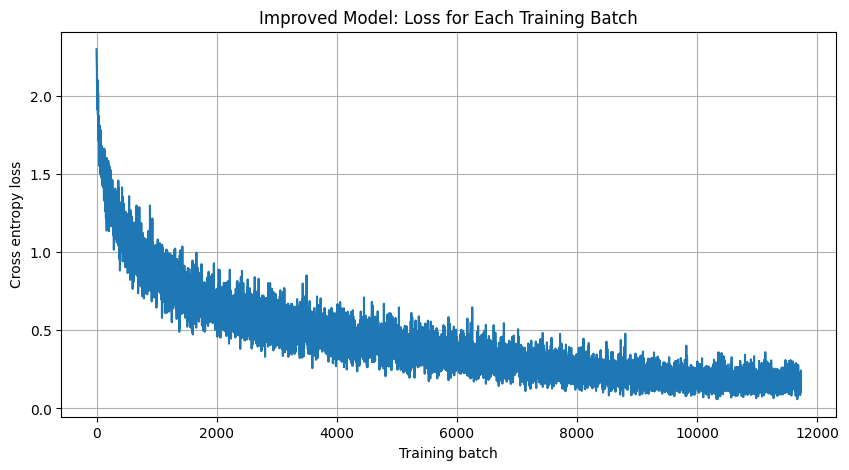

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(all_batch_losses)
plt.xlabel("Training batch")
plt.ylabel("Cross entropy loss")
plt.title("Improved Model: Loss for Each Training Batch")
plt.grid(True)
plt.show()

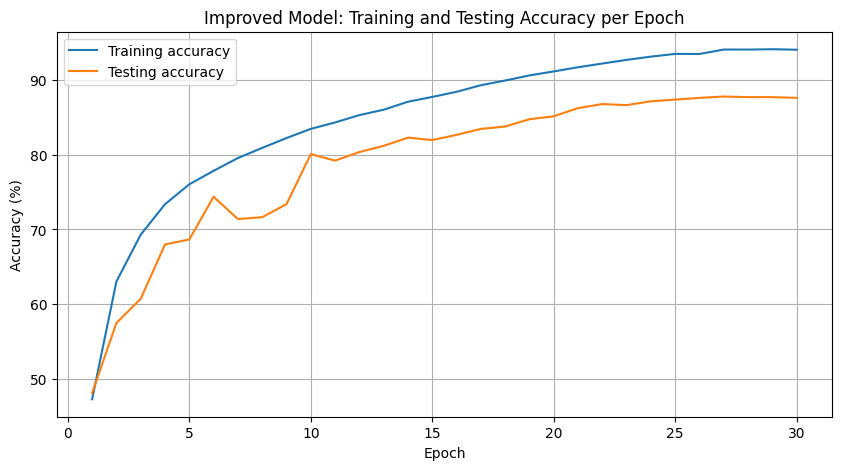

In [ ]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_accuracies, label="Training accuracy")
plt.plot(epochs, test_accuracies, label="Testing accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Improved Model: Training and Testing Accuracy per Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
best_test_accuracy = max(test_accuracies)
best_epoch = test_accuracies.index(best_test_accuracy) + 1

print(f"Best test accuracy: {best_test_accuracy:.2f}%")
print(f"Best epoch: {best_epoch}")

Best test accuracy: 87.81%
Best epoch: 27


## Final Part 1 Summary

The initial model achieved a highest testing accuracy of 84.76%. The improved model increased the number of channels and convolutional layers per intermediate block and was trained for 30 epochs using AdamW, weight decay, data augmentation, and cosine learning-rate scheduling.

The best testing accuracy achieved by the improved model was 87.81% at epoch 27.